In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

## Data Types in Pandas

- **Objects** : strings and characters
- **int64** : integers
- **float64** : decimals

#### Identifying Data types and correction

data types of a column can be identifies using the method `dataframes.dtypes()` and to change the data type, `df["price"] = df["price'].astype("int")`


## Simple techniques in data analysis

- **Handling missing values**: If certain values in a given row are missing, there are many ways to handle them:
    -  Replacing the missing values with the mean or the most frequently occuring quantity, use `.replace( missing_value , replaced_value)` method. Missing Values may be empty, ? or Not a Number (NaN) quantities. For NaN use `np.nan`.  
    -  Excluding that data entry from analysis or omitting that value from that column. use code

       `df.dropna(subset = ['column_name'] , axis = 0 , inplace = true)`

       drops the row of missing value when axis = 0. If axis = 1 then the column is dropped. The `inplace = true` argument ensures that changes take place in the original database, otherwise a new database will be created, and the original will remain unchanged.

- **Normalisation**: Helps in normalising variables to ensure that they have similar impact on the outcome so that it is not overly dependent on changes in a single input, such as while studying the relation of age of an individual to salary, salary numbers will be in thousands while age in tens, so normalising both the variables is necessary. Various ways can be used for normalising such as:

    - **Simple feature scaling**:  It ranges from 0 to 1 $$x_{new} = \frac{x_{old}}{x_{max}}$$
      code: `df['column_name'] = df['column_name']/df['column_name'].max()`
    - **Min-Max**: It ranges from 0 to 1 $$x_{new} = \frac{x_{old} - x_{min}}{x_{max} - x_{min}}$$
      code: use `.min()` and `.max()` functions on `df['column_name']` using subtraction(-) and division(/) operators
    - **Z-score or Standard Score**: Values are distributed around 0, typically ranging from -3 to 3. Variables that are more precise (ie having low $\sigma$ ) are assigned higher values. $$x_{new} = \frac{x_{old} - \mu}{\sigma}$$
      code: use `.mean()` and `.std()` functions for mean and standard deviation respectively.



In [2]:
df = pd.read_csv("C:/Users/himan/Downloads/laptop_pricing.csv")

#adding column titles using df.columns method
headers = ("Company" , "Units_sold" , "Screen_type" , "Units_left" , "units_ordered" , "units_stored" ,
           "Screen_size" , "dont_know" , "RAM" , "ROM" , "dont_know" , "$")

df.columns = headers 
df["Units_sold"] = df["Units_sold"].astype("int")
df.head(5)


,Company,Units_sold,Screen_type,Units_left,units_ordered,units_stored,Screen_size,dont_know,RAM,ROM,dont_know,$
0,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.2,634
1,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.2,946
2,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
3,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837
4,Dell,3,Full HD,1,1,5,39.624,1.6,8,256,2.2,1016


In [3]:
#Replacing missing values with higher frequency
#idx_max finds out the values with the highest frequency
x = df['Screen_size'].value_counts().idxmax() 
df["Screen_size"].replace("?" , x ) #using inplace = true would make the changes into the original file

df["Screen_size"].value_counts()

Screen_size
39.624    89
35.56     63
38.1      23
33.782    20
33.02     18
43.942     7
43.18      5
31.75      4
30.48      4
?          4
Name: count, dtype: int64

In [4]:
df["Screen_type"].value_counts()

Screen_type
Full HD      161
IPS Panel     76
Name: count, dtype: int64

### Groupby
**Groupby** method can be used to study relationships between different categories of variables using the code `df.groupby()`. 

In [5]:
df_test = df[['Screen_type' , 'RAM' , '$']] #choose the columns 
df_group = df_test.groupby(['Screen_type' , 'RAM'] , as_index = False).mean() #choose columns for grouping
#mean is used to show the average price
df_group.pivot(index = "RAM" , columns = "Screen_type") #pivot method organises tables better

$             
Screen_type      Full HD    IPS Panel
RAM                                  
4             907.608696   914.900000
6             827.800000   837.000000
8            1493.262295  1548.655738
12                   NaN  2125.000000
16           2445.454545  2129.666667

## Bins for plotting data

**Binning** : Binning is a process of creating a categorical attribute which splits the values of a continuous data into a specified number of groups. Pandas `pd.cut( df[column_name] , bins , label_names)` method is used to segment and sort the data values into bins, and the bins are created using `np.linspace(min(df) , max(df) , number_of_bins)` method and then passed to the cut method. The cut method divides the dataset to equal width segments (unless we choose custom width) and then checks which data lies in which segment.

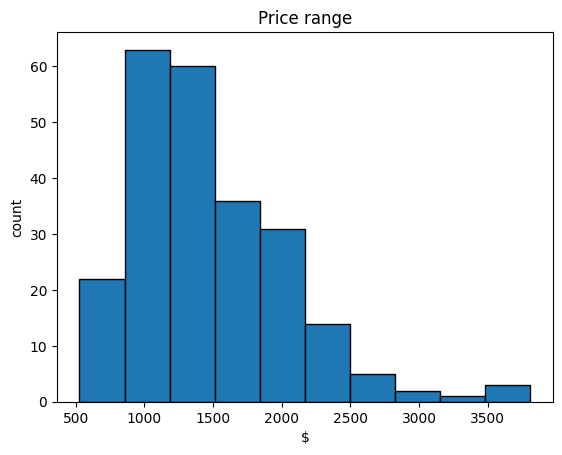

In [6]:
#plt.hist( df["$"] , 4) #histogram 
plt.xlabel("$")
plt.ylabel("count")
plt.title("Price range")
plt.hist(df["$"] , edgecolor = 'black')
plt.show()

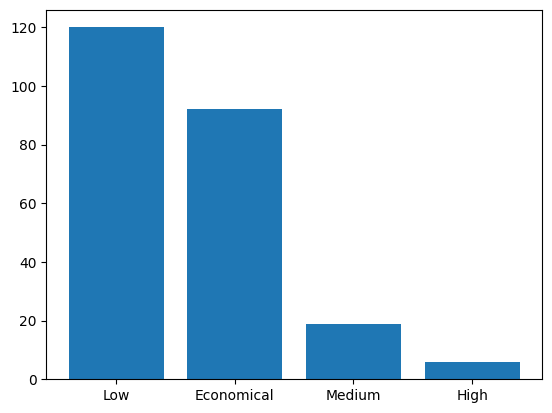

In [7]:
bins = np.linspace(min(df["$"]) , max(df["$"]) , 5)
bins
group_names = [ 'Low' , 'Economical', 'Medium' , 'High']
df["Price-bins"] = pd.cut(df["$"] , bins , labels = group_names , include_lowest = True)
df[["$" , "Price-bins"]].tail(20)
plt.bar(group_names , df["Price-bins"].value_counts())
plt.show()
#plt.hist(df["$"] , 4)

## Categorical variables to quantitative variables

Numerical values are used to label categories, to do numerical analysis of data. For this we use **indicator/ dummy variables**, which are  numerical values assigned to categories. These can be accessed using the pandas get_dummies method `pd.get_dummies(df[column_name])`. We can use this to analyse Screen type of laptops (OLED or IPS), or fuel types of vehicles for later regression analysis.

In [8]:
dummy_var = pd.get_dummies(df["Screen_type"] , dtype = int)
dummy_var.rename(columns = {'Full HD' : 'OLED' , 'IPS Panel' : 'IPS'} , inplace = True)
dummy_var.head()
df = pd.concat([df , dummy_var] , axis = 1)
df.head()
df.drop({'Screen_type'} , axis = 1 ,inplace =True)
df.head()

,Company,Units_sold,Units_left,units_ordered,units_stored,Screen_size,dont_know,RAM,ROM,dont_know,$,Price-bins,OLED,IPS
0,Dell,3,1,1,3,39.624,2.0,4,256,2.2,634,Low,1,0
1,Dell,3,1,1,7,39.624,2.7,8,256,2.2,946,Low,1,0
2,Dell,4,2,1,5,33.782,1.6,8,128,1.22,1244,Low,0,1
3,HP,4,2,1,7,39.624,1.8,8,256,1.91,837,Low,1,0
4,Dell,3,1,1,5,39.624,1.6,8,256,2.2,1016,Low,1,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Company        237 non-null    object  
 1   Units_sold     237 non-null    int64   
 2   Units_left     237 non-null    int64   
 3   units_ordered  237 non-null    int64   
 4   units_stored   237 non-null    int64   
 5   Screen_size    237 non-null    object  
 6   dont_know      237 non-null    float64 
 7   RAM            237 non-null    int64   
 8   ROM            237 non-null    int64   
 9   dont_know      237 non-null    object  
 10  $              237 non-null    int64   
 11  Price-bins     237 non-null    category
 12  OLED           237 non-null    int64   
 13  IPS            237 non-null    int64   
dtypes: category(1), float64(1), int64(9), object(3)
memory usage: 24.6+ KB


In [10]:
#To save the final data in csv format
df.to_csv('Laptop_data.csv')

## Making a Boxplot

In [11]:
import seaborn as sns

**Boxplots** are used to visualise numeric data, where the middle line is the median, the upper quartile (top of shaded rectangle) shows where the 75th percentile is, the lower quartile (bottom of shaded rectangle) shows where the 25th percentile is. The data between the upper and lower quartile represents the inter-quartile range (IQR). The lower and upper extremes are calculated as 1.5 times the inter-quartile range above the 75th percentile, and as 1.5 times the IQR below the 25th percentile. The individual dots representa the outliers. 

<Axes: xlabel='RAM', ylabel='$'>

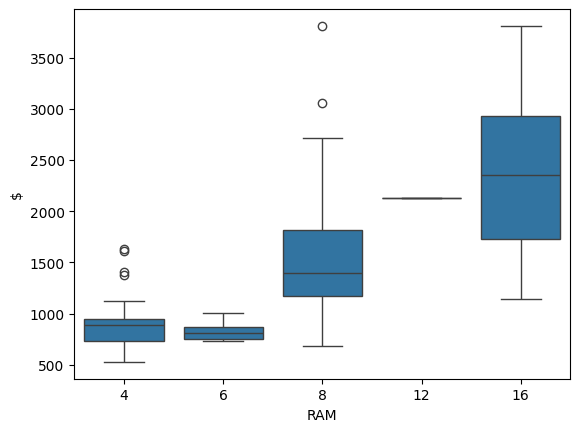

In [12]:
sns.boxplot( x = 'RAM' , y = '$' , data = df)

## Scatter Plots
In scatter plots observations are represented as a collection of data points. Scatter plots are useful to study continuous variables. It is used to study relationship between continuous variables, with the independent/predictor variable on x axis and dependent/target variable on y axis.

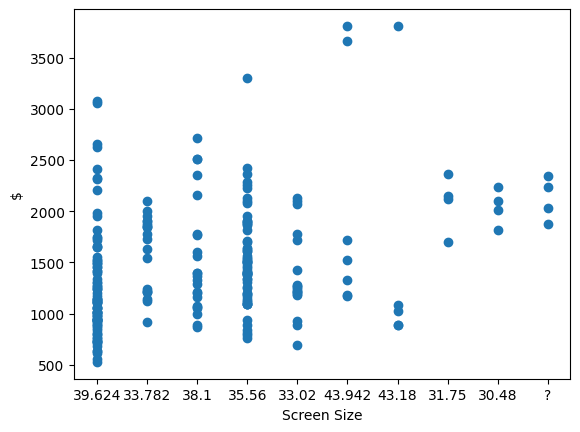

In [13]:
x = df["Screen_size"]
y = df["$"]
plt.xlabel("Screen Size")
plt.ylabel("$")
plt.scatter(x,y)